In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic

In [6]:
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *

In [7]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [ ]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [30]:
from waymo_agent.models.evaluate import *

### Heuristic Agents

In [31]:
config = EnvConfig(max_episode_steps=60 * 3)
plt_cfg = PlotConfig()
env_heuristic = RideShareEnv(config, plot_config=plt_cfg)

Assigned lambda values to nodes. Total lambda: 2.2572 (target: 2.3460)


In [32]:
price_agent = PricingAgent(env_heuristic.config)
dispatch_agent = DispatchAgent(env_heuristic)
reposition_agent = RepositionAgent(env_heuristic)
agents = (price_agent, dispatch_agent, reposition_agent)

### Actor-Critic PPO Model

In [33]:
config = EnvConfig(max_episode_steps=60 * 3)
plt_cfg = PlotConfig()
env_model = RideShareEnv(config, plt_cfg)

Assigned lambda values to nodes. Total lambda: 2.2790 (target: 2.3460)


In [34]:
cfg_ppo = PPOTrainConfig()
model = RideShareActorCritic(env_model)
load_weights(model, MODEL_WEIGHT_DIR / "ppo_model_final.pt", DEVICE_TORCH_STR)

RideShareActorCritic(
  (encoder): Sequential(
    (0): Linear(in_features=944, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (price_mu): Linear(in_features=256, out_features=50, bias=True)
  (repo_mu): Linear(in_features=256, out_features=48, bias=True)
  (dispatch_logits): Linear(in_features=256, out_features=1250, bias=True)
  (value): Linear(in_features=256, out_features=1, bias=True)
)

In [ ]:
r, info = run_episode(
    env_model,
    policy_fn=ppo_policy(model),
    seed=0,
    show_progress=True,
    desc="PPO rollout",
)

PPO rollout:   0%|          | 0/180 [00:00<?, ?step/s]

In [37]:
r, info = run_episode(
    env_heuristic,
    policy_fn=heuristic_policy(agents),
    seed=0,
    show_progress=True,
    desc="Heuristic rollout",
)

Heuristic rollout:   0%|          | 0/180 [00:00<?, ?step/s]

In [41]:
seeds = list(range(5))
results = eval_paired_seeds(
    env_model,
    env_heuristic,
    ppo_policy(model),  # policy fn
    heuristic_policy(agents),  # policy fn
    seeds=seeds,
)
results

Evaluating policies:   0%|          | 0/5 [00:00<?, ?seed/s]

{'seeds': array([0, 1, 2, 3, 4]),
 'ppo': array([0., 0., 0., 0., 0.]),
 'heur': array([218.81002762, 273.65445774, 181.13185881, 221.26813135,
        281.15858896]),
 'diff': array([-218.81002762, -273.65445774, -181.13185881, -221.26813135,
        -281.15858896]),
 'ppo_mean': 0.0,
 'ppo_std': 0.0,
 'heur_mean': 235.20461289558574,
 'heur_std': 41.764306418983665,
 'diff_mean': -235.20461289558574,
 'diff_std': 41.764306418983665,
 'win_rate': 0.0}

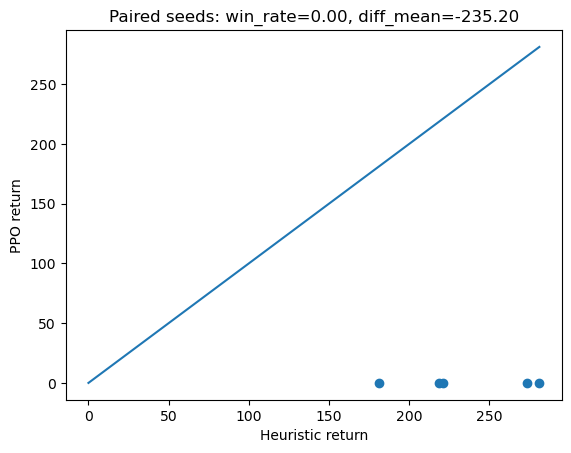

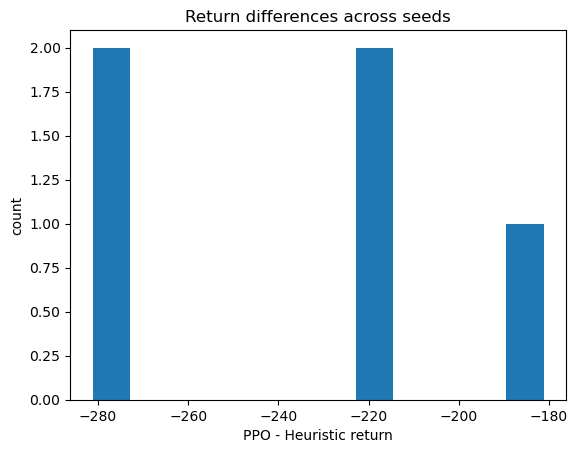

In [42]:
plot_min_eval(results)

In [ ]:
plot_learning_curve_vs_baseline(logs, results["heur_mean"])

KeyError: 'eval_return'

In [44]:
results.keys()

dict_keys(['seeds', 'ppo', 'heur', 'diff', 'ppo_mean', 'ppo_std', 'heur_mean', 'heur_std', 'diff_mean', 'diff_std', 'win_rate'])